# Ensemble Learning: Random Forest vs XGBoost

## NeuroFive ML Internship – Week 4

**Author:** Muhammad Fahad

### Objective

The objective of this project is to compare ensemble learning models (Random Forest and XGBoost) with a previous single machine learning model (Logistic Regression). We will evaluate their performance, analyze feature importance, and understand how ensemble methods improve prediction accuracy.

In [5]:
!pip install xgboost

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from xgboost import XGBClassifier

## Step 1 – Load and Explore the Dataset

In this step, we load the Titanic dataset and examine its structure before applying preprocessing techniques.

In [4]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Shape:", df.shape)

df.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 2 – Data Cleaning

Missing values are handled before training the models.

- Age → Filled with median
- Embarked → Filled with mode
- Cabin → Dropped due to excessive missing values

In [7]:
# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin
df = df.drop("Cabin", axis=1)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Step 3 – Feature Engineering

Two new features are created to improve model performance.

- FamilySize = SibSp + Parch + 1
- IsAlone = Indicates whether a passenger was traveling alone

In [8]:
# Create FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Create IsAlone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[["SibSp","Parch","FamilySize","IsAlone"]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Step 4 – Feature Selection

The selected features are prepared for model training, and the target variable is separated.

In [9]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df[features]
y = df["Survived"]

print(X.head())
print(y.head())

   Pclass     Sex   Age     Fare Embarked  FamilySize  IsAlone
0       3    male  22.0   7.2500        S           2        0
1       1  female  38.0  71.2833        C           2        0
2       3  female  26.0   7.9250        S           1        1
3       1  female  35.0  53.1000        S           2        0
4       3    male  35.0   8.0500        S           1        1
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


## Step 5 – Encode Categorical Variables

Categorical columns are converted into numerical format using One-Hot Encoding because machine learning models cannot process text values directly.

In [10]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Pclass,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,2,0,True,False,True
1,1,38.0,71.2833,2,0,False,False,False
2,3,26.0,7.9250,1,1,False,False,True
3,1,35.0,53.1000,2,0,False,False,True
4,3,35.0,8.0500,1,1,True,False,True


## Step 6 – Split the Dataset

The dataset is divided into training and testing sets.

- Training Data: 70%
- Testing Data: 30%

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (623, 8)
Testing: (268, 8)


## Step 7 – Train Logistic Regression

Logistic Regression is used as the baseline model. We will compare its performance with ensemble learning models.

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.8059701492537313


## Step 8 – Train Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7761194029850746


## Step 9 – Train XGBoost

XGBoost is a boosting algorithm that builds trees sequentially, where each new tree focuses on correcting the mistakes made by the previous trees.

In [14]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.7910447761194029


## Step 10 – Compare Model Performance

The performance of all three models is compared using accuracy.

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_acc,
        rf_acc,
        xgb_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.805970
1,Random Forest,0.776119
2,XGBoost,0.791045


## Step 11 – Feature Importance

Feature importance helps identify which features contribute the most to the model's predictions.

We will compare feature importance for:

- Random Forest
- XGBoost

      Feature  Importance
2        Fare    0.279958
1         Age    0.261900
5    Sex_male    0.253268
0      Pclass    0.086710
3  FamilySize    0.060455
7  Embarked_S    0.027917
4     IsAlone    0.017657
6  Embarked_Q    0.012135


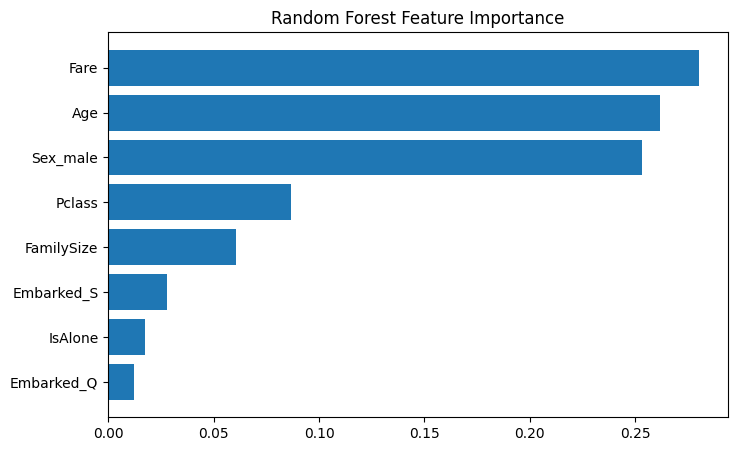

In [17]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    rf_importance["Feature"][:10],
    rf_importance["Importance"][:10]
)
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

      Feature  Importance
5    Sex_male    0.547439
0      Pclass    0.230894
3  FamilySize    0.055151
7  Embarked_S    0.053442
1         Age    0.043510
2        Fare    0.043169
6  Embarked_Q    0.026395
4     IsAlone    0.000000


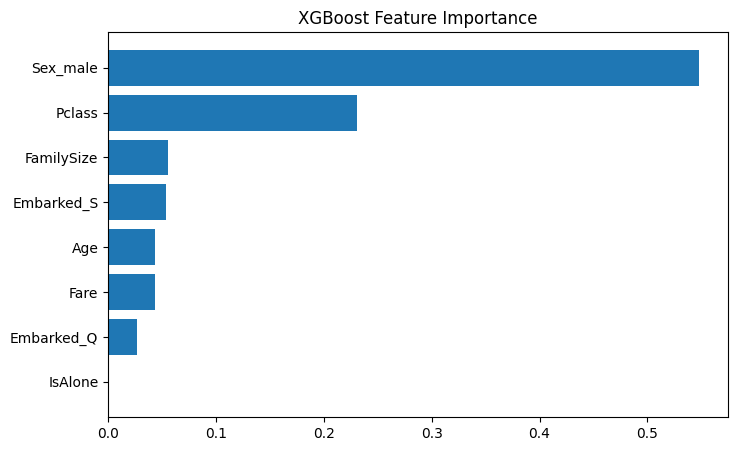

In [18]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    xgb_importance["Feature"][:10],
    xgb_importance["Importance"][:10]
)
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Step 12 – Model Comparison Summary

### Random Forest

Random Forest builds many decision trees independently and combines their predictions using majority voting. It reduces overfitting and generally performs better than a single decision tree.

### XGBoost

XGBoost builds decision trees sequentially, where each new tree learns from the errors of previous trees. It often provides higher accuracy but may require hyperparameter tuning.

### Comparison

In this project, Logistic Regression achieved the highest accuracy, while Random Forest and XGBoost produced slightly lower accuracy using their default settings. This shows that the best model depends on the dataset rather than the complexity of the algorithm.